AND Gate


In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

print("AND Output:", MCP_Neurons_AND(X1, X2, T))

AND Output: [0, 0, 0, 1]


OR Gate

In [2]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# ✅ Define inputs FIRST
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

# ✅ Then call function
T = 1
print("OR Output:", MCP_Neurons_OR(X1, X2, T))

OR Output: [0, 1, 1, 1]


Load Dataset


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/AI/mnist_0_and_1.csv")

X = df.drop(columns=["label"]).values
y = df["label"].values

print(X.shape)
print(y.shape)

(12665, 784)
(12665,)


Initialize Weights

In [5]:
weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.1
epochs = 100

Decision Function

In [6]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return np.where(predictions >= 0, 1, 0)

Train Perceptron

In [7]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred == y[i]:
                correct += 1
            else:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

        accuracy = correct / len(X)

    return weights, bias, accuracy

Train Model

In [8]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 1.0


Misclassified Images

In [9]:
import matplotlib.pyplot as plt

predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

All images were correctly classified!


Load Dataset

In [11]:
df = pd.read_csv("/content/drive/MyDrive/AI/mnist_3_and_5.csv")

X = df.drop(columns=["label"]).values
y = df["label"].values

In [12]:
weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy (3 vs 5):", accuracy)

Final Accuracy (3 vs 5): 0.0


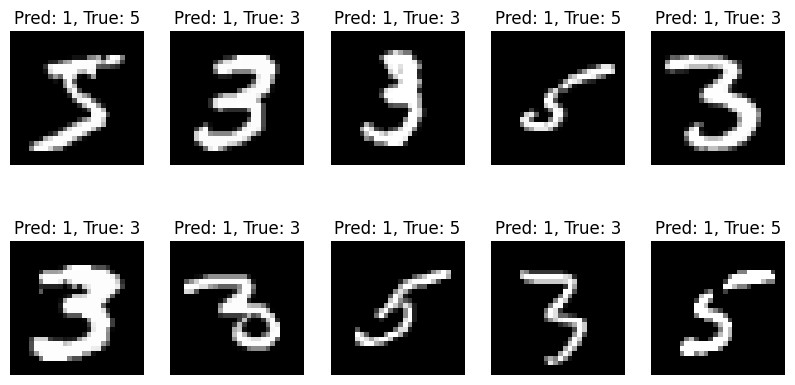

In [13]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")